# Week 2 Lab: Dynamic Programming

**Topics:**
- Policy evaluation (prediction problem)
- Policy improvement theorem
- Policy iteration
- Value iteration
- Generalized policy iteration framework
- Gymnasium environments as known MDPs
- Accessing environment dynamics: `env.unwrapped` and transition models
- Discrete vs. continuous state/action spaces
- Working with tabular representations
- NumPy for value tables and policy arrays
- Efficient matrix operations for DP sweeps

**Learning Objectives:**
- Implement classical DP algorithms for known MDPs
- Understand the policy improvement theorem and GPI framework
- Analyze convergence properties and computational requirements
- Recognize when DP is applicable vs. other methods
- Navigate Gymnasium’s environment structure for model‑based planning

## 0. Setup and Imports

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import gymnasium as gym
import time
from typing import Tuple, List, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

# For reproducibility
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Custom GridWorld Environment

We will create a configurable GridWorld environment that follows the Gymnasium API.  
It supports:
- Deterministic or stochastic transitions.
- Custom board size, start, goal, and obstacle cells.
- Rewards per step and for reaching the goal.

### 1.1 Environment Implementation

In [2]:
class GridWorld(gym.Env):
    """
    Configurable GridWorld environment with deterministic or stochastic transitions.

    The grid is represented as a 2D array. State index = row * n_cols + col.

    Actions: 0=Up, 1=Right, 2=Down, 3=Left.
    """
    metadata = {'render_modes': ['human', 'rgb_array'], 'render_fps': 4}

    def __init__(self, size: int = 4, start: Tuple[int, int] = (0, 0),
                 goal: Tuple[int, int] = (3, 3), obstacles: List[Tuple[int, int]] = None,
                 step_reward: float = -0.1, goal_reward: float = 1.0,
                 stochastic: bool = False, slip_prob: float = 0.2):
        """
        Args:
            size: Grid size (size x size).
            start: (row, col) of start state.
            goal: (row, col) of goal state.
            obstacles: List of (row, col) for obstacle cells.
            step_reward: Reward for each step (default -0.1).
            goal_reward: Reward when reaching the goal.
            stochastic: If True, transitions are stochastic.
            slip_prob: Probability of slipping to a perpendicular direction
                       (only used if stochastic=True).
        """
        super().__init__()
        self.size = size
        self.n_rows = size
        self.n_cols = size
        self.nS = size * size
        self.nA = 4  # 0:Up, 1:Right, 2:Down, 3:Left
        self.action_meanings = ['↑', '→', '↓', '←']

        self.start = start
        self.goal = goal
        self.obstacles = obstacles if obstacles is not None else []
        self.step_reward = step_reward
        self.goal_reward = goal_reward
        self.stochastic = stochastic
        self.slip_prob = slip_prob

        # Terminal states (goal is absorbing; obstacles are terminal with no reward)
        self.terminal_states = [self.goal] + self.obstacles

        # Build transition dynamics: P[s][a] = [(prob, next_state, reward, done), ...]
        self.P = self._build_transitions()

        # For Gym compliance
        self.observation_space = gym.spaces.Discrete(self.nS)
        self.action_space = gym.spaces.Discrete(self.nA)

        self.s = None

    def _state_to_rc(self, s: int) -> Tuple[int, int]:
        return divmod(s, self.n_cols)

    def _rc_to_state(self, r: int, c: int) -> int:
        return r * self.n_cols + c

    def _build_transitions(self):
        P = {s: {a: [] for a in range(self.nA)} for s in range(self.nS)}

        # Action deltas: Up, Right, Down, Left
        deltas = [(-1, 0), (0, 1), (1, 0), (0, -1)]

        for s in range(self.nS):
            r, c = self._state_to_rc(s)

            # Check terminal
            if (r, c) in self.terminal_states:
                for a in range(self.nA):
                    P[s][a] = [(1.0, s, 0.0, True)]
                continue

            for a in range(self.nA):
                intended_dr, intended_dc = deltas[a]

                if not self.stochastic:
                    # Deterministic
                    nr = max(0, min(self.n_rows - 1, r + intended_dr))
                    nc = max(0, min(self.n_cols - 1, c + intended_dc))
                    next_s = self._rc_to_state(nr, nc)
                    done = (nr, nc) in self.terminal_states
                    reward = self.goal_reward if (nr, nc) == self.goal else self.step_reward
                    P[s][a] = [(1.0, next_s, reward, done)]
                else:
                    # Stochastic: 1-slip_prob to go intended, slip_prob/2 to each perpendicular
                    results = []
                    # Perpendicular actions: (a-1)%4 and (a+1)%4
                    perp_actions = [(a - 1) % 4, (a + 1) % 4]
                    actions_probs = [(a, 1.0 - self.slip_prob),
                                     (perp_actions[0], self.slip_prob / 2),
                                     (perp_actions[1], self.slip_prob / 2)]

                    for act, prob in actions_probs:
                        dr, dc = deltas[act]
                        nr = max(0, min(self.n_rows - 1, r + dr))
                        nc = max(0, min(self.n_cols - 1, c + dc))
                        next_s = self._rc_to_state(nr, nc)
                        done = (nr, nc) in self.terminal_states
                        reward = self.goal_reward if (nr, nc) == self.goal else self.step_reward
                        results.append((prob, next_s, reward, done))
                    P[s][a] = results

        return P

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.s = self._rc_to_state(*self.start)
        return self.s, {}

    def step(self, action):
        transitions = self.P[self.s][action]
        probs = [t[0] for t in transitions]
        idx = np.random.choice(len(transitions), p=probs)
        prob, next_s, reward, done = transitions[idx]
        self.s = next_s
        return next_s, reward, done, False, {}

    def render(self):
        grid = np.full((self.n_rows, self.n_cols), ' ')
        grid[self.start] = 'S'
        grid[self.goal] = 'G'
        for obs in self.obstacles:
            grid[obs] = 'X'
        if self.s is not None:
            r, c = self._state_to_rc(self.s)
            grid[r, c] = 'A'  # Agent
        print('\n'.join([' '.join(row) for row in grid]))
        print()

# Quick test
env = GridWorld(size=4, stochastic=False)
print("Deterministic GridWorld created. States:", env.nS, "Actions:", env.nA)
env = GridWorld(size=4, stochastic=True, slip_prob=0.2)
print("Stochastic GridWorld created.")

Deterministic GridWorld created. States: 16 Actions: 4
Stochastic GridWorld created.


### 1.2 Helper Functions for Visualization

In [3]:
def plot_value_function(V: np.ndarray, env: GridWorld, ax=None, title="Value Function"):
    """Plot value function as a heatmap."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,5))
    im = ax.imshow(V.reshape(env.n_rows, env.n_cols), cmap='viridis')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # Annotate cells
    for s in range(env.nS):
        r, c = env._state_to_rc(s)
        ax.text(c, r, f'{V[s]:.2f}', ha='center', va='center', color='w', fontsize=8)
    ax.set_xticks(range(env.n_cols))
    ax.set_yticks(range(env.n_rows))
    ax.set_title(title)
    return ax

def plot_policy(policy: np.ndarray, env: GridWorld, ax=None, title="Policy"):
    """Plot policy as arrows on grid."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,5))
    # Draw grid
    for i in range(env.n_rows+1):
        ax.axhline(i-0.5, color='gray', lw=0.5)
        ax.axvline(i-0.5, color='gray', lw=0.5)
    # Draw obstacles/goal/start
    for r in range(env.n_rows):
        for c in range(env.n_cols):
            s = env._rc_to_state(r, c)
            if (r, c) == env.goal:
                ax.text(c, r, 'G', ha='center', va='center', fontsize=14, fontweight='bold', color='green')
            elif (r, c) == env.start:
                ax.text(c, r, 'S', ha='center', va='center', fontsize=14, fontweight='bold', color='blue')
            elif (r, c) in env.obstacles:
                ax.text(c, r, 'X', ha='center', va='center', fontsize=14, fontweight='bold', color='red')
            else:
                # Draw arrow for deterministic policy (if policy is deterministic)
                if np.sum(policy[s]) > 0.99:  # deterministic enough
                    a = np.argmax(policy[s])
                    dx, dy = {0: (0, -0.3), 1: (0.3, 0), 2: (0, 0.3), 3: (-0.3, 0)}[a]
                    ax.arrow(c, r, dx, dy, head_width=0.15, head_length=0.15, fc='black', ec='black')
    ax.set_xlim(-0.5, env.n_cols-0.5)
    ax.set_ylim(-0.5, env.n_rows-0.5)
    ax.invert_yaxis()
    ax.set_xticks(range(env.n_cols))
    ax.set_yticks(range(env.n_rows))
    ax.set_title(title)
    return ax

## 2. DP Algorithms Implementation

We will implement both synchronous and in‑place versions where applicable.

### 2.1 Policy Evaluation

**Synchronous:** Use two arrays (old and new V) to update all states simultaneously.  
**In‑place:** Use a single array and update states sequentially, using the most recent values for bootstrapping.

In [4]:
def policy_evaluation_sync(env: GridWorld, policy: np.ndarray, gamma: float = 0.9,
                           theta: float = 1e-6, max_iter: int = 10000) -> Tuple[np.ndarray, List[float]]:
    """
    Synchronous policy evaluation.
    Returns: (V, delta_history)
    """
    V = np.zeros(env.nS)
    delta_history = []
    for _ in range(max_iter):
        delta = 0.0
        V_new = np.zeros_like(V)
        for s in range(env.nS):
            v = 0.0
            for a in range(env.nA):
                for prob, next_s, reward, done in env.P[s][a]:
                    v += policy[s, a] * prob * (reward + gamma * V[next_s] * (not done))
            V_new[s] = v
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new
        delta_history.append(delta)
        if delta < theta:
            break
    return V, delta_history

def policy_evaluation_inplace(env: GridWorld, policy: np.ndarray, gamma: float = 0.9,
                              theta: float = 1e-6, max_iter: int = 10000) -> Tuple[np.ndarray, List[float]]:
    """
    In‑place policy evaluation (updates V array directly).
    """
    V = np.zeros(env.nS)
    delta_history = []
    for _ in range(max_iter):
        delta = 0.0
        for s in range(env.nS):
            v_old = V[s]
            v = 0.0
            for a in range(env.nA):
                for prob, next_s, reward, done in env.P[s][a]:
                    v += policy[s, a] * prob * (reward + gamma * V[next_s] * (not done))
            V[s] = v
            delta = max(delta, abs(v - v_old))
        delta_history.append(delta)
        if delta < theta:
            break
    return V, delta_history

### 2.2 Policy Improvement

In [5]:
def policy_improvement(env: GridWorld, V: np.ndarray, gamma: float = 0.9) -> Tuple[np.ndarray, bool]:
    """
    Greedy policy improvement.
    Returns: (new_policy, is_stable)
    """
    policy = np.zeros((env.nS, env.nA))
    stable = True
    for s in range(env.nS):
        q_values = np.zeros(env.nA)
        for a in range(env.nA):
            for prob, next_s, reward, done in env.P[s][a]:
                q_values[a] += prob * (reward + gamma * V[next_s] * (not done))
        best_a = np.argmax(q_values)
        policy[s, best_a] = 1.0
        # If there was a previous policy, we could check stability; we'll do it later in PI loop.
    return policy, stable

### 2.3 Policy Iteration

In [6]:
def policy_iteration(env: GridWorld, gamma: float = 0.9, theta: float = 1e-6,
                     inplace_eval: bool = True) -> Tuple[np.ndarray, np.ndarray, List[int], float]:
    """
    Policy iteration.
    Returns: (optimal_policy, optimal_V, eval_iters_per_outer, total_time)
    """
    policy = np.ones((env.nS, env.nA)) / env.nA  # uniform random
    V = np.zeros(env.nS)
    eval_iters = []
    start_time = time.time()

    eval_func = policy_evaluation_inplace if inplace_eval else policy_evaluation_sync

    while True:
        # Policy evaluation
        V, deltas = eval_func(env, policy, gamma, theta)
        eval_iters.append(len(deltas))

        # Policy improvement
        new_policy, _ = policy_improvement(env, V, gamma)
        if np.array_equal(new_policy, policy):
            break
        policy = new_policy

    total_time = time.time() - start_time
    return policy, V, eval_iters, total_time

### 2.4 Value Iteration

In [7]:
def value_iteration(env: GridWorld, gamma: float = 0.9, theta: float = 1e-6,
                    inplace: bool = True) -> Tuple[np.ndarray, np.ndarray, List[float], float]:
    """
    Value iteration.
    Returns: (optimal_policy, optimal_V, delta_history, total_time)
    """
    V = np.zeros(env.nS)
    delta_history = []
    start_time = time.time()

    while True:
        delta = 0.0
        if inplace:
            # In‑place (standard VI)
            for s in range(env.nS):
                v_old = V[s]
                q_values = np.zeros(env.nA)
                for a in range(env.nA):
                    for prob, next_s, reward, done in env.P[s][a]:
                        q_values[a] += prob * (reward + gamma * V[next_s] * (not done))
                V[s] = np.max(q_values)
                delta = max(delta, abs(V[s] - v_old))
        else:
            # Synchronous VI (using two arrays)
            V_new = np.zeros_like(V)
            for s in range(env.nS):
                q_values = np.zeros(env.nA)
                for a in range(env.nA):
                    for prob, next_s, reward, done in env.P[s][a]:
                        q_values[a] += prob * (reward + gamma * V[next_s] * (not done))
                V_new[s] = np.max(q_values)
                delta = max(delta, abs(V_new[s] - V[s]))
            V = V_new
        delta_history.append(delta)
        if delta < theta:
            break

    # Extract greedy policy
    policy, _ = policy_improvement(env, V, gamma)
    total_time = time.time() - start_time
    return policy, V, delta_history, total_time

## 3. Experiments on GridWorld

We'll test on two configurations:
1. **Deterministic** 4x4 GridWorld with a simple layout.
2. **Stochastic** 4x4 GridWorld with slip probability.

### 3.1 Deterministic GridWorld

In [8]:
# Create environment
env_det = GridWorld(size=4, start=(0,0), goal=(3,3), obstacles=[(1,1), (2,2)],
                    step_reward=-0.1, goal_reward=1.0, stochastic=False)

print("Deterministic GridWorld:")
env_det.render()

Deterministic GridWorld:
S      
  X    
    X  
      G



### 3.2 Policy Iteration (In‑place Evaluation)

In [9]:
policy_pi_det, V_pi_det, eval_iters_pi_det, time_pi_det = policy_iteration(env_det, gamma=0.9, inplace_eval=True)
print(f"Policy Iteration converged. Outer iterations: {len(eval_iters_pi_det)}. Total time: {time_pi_det:.4f}s")
print(f"Evaluation sweeps per outer iteration: {eval_iters_pi_det}")

Policy Iteration converged. Outer iterations: 4. Total time: 0.0048s
Evaluation sweeps per outer iteration: [39, 4, 5, 7]


### 3.3 Value Iteration (In‑place)

In [10]:
policy_vi_det, V_vi_det, deltas_vi_det, time_vi_det = value_iteration(env_det, gamma=0.9, inplace=True)
print(f"Value Iteration converged. Sweeps: {len(deltas_vi_det)}. Total time: {time_vi_det:.4f}s")

Value Iteration converged. Sweeps: 7. Total time: 0.0014s


### 3.4 Visualizations for Deterministic Case

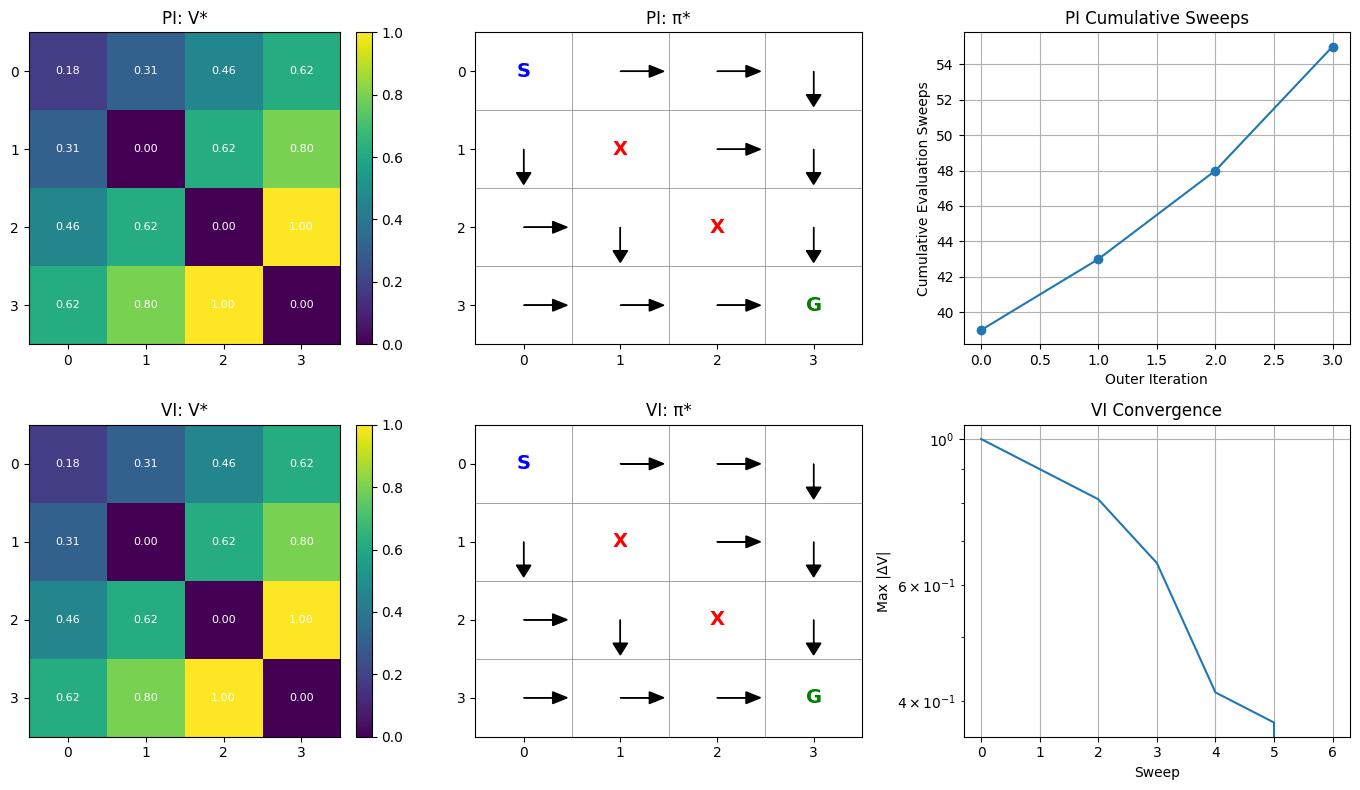

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Value functions
plot_value_function(V_pi_det, env_det, ax=axes[0,0], title="PI: V*")
plot_policy(policy_pi_det, env_det, ax=axes[0,1], title="PI: π*")
axes[0,2].plot(np.cumsum(eval_iters_pi_det), marker='o')
axes[0,2].set_xlabel("Outer Iteration")
axes[0,2].set_ylabel("Cumulative Evaluation Sweeps")
axes[0,2].set_title("PI Cumulative Sweeps")
axes[0,2].grid(True)

plot_value_function(V_vi_det, env_det, ax=axes[1,0], title="VI: V*")
plot_policy(policy_vi_det, env_det, ax=axes[1,1], title="VI: π*")
axes[1,2].plot(deltas_vi_det)
axes[1,2].set_xlabel("Sweep")
axes[1,2].set_ylabel("Max |ΔV|")
axes[1,2].set_title("VI Convergence")
axes[1,2].set_yscale('log')
axes[1,2].grid(True)

plt.tight_layout()
plt.show()

### 3.5 Compare In‑place vs Synchronous for Policy Evaluation

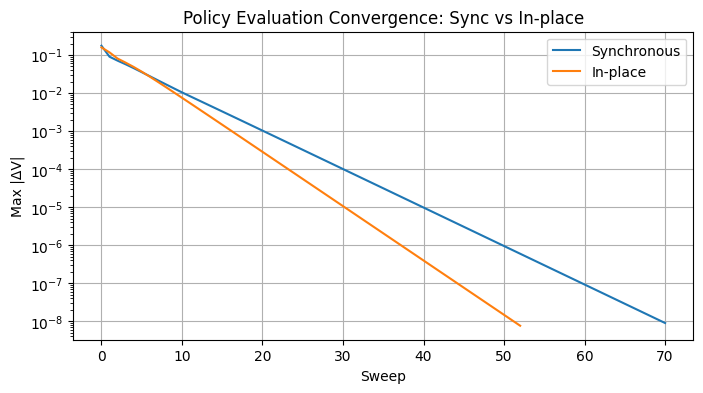

Synchronous sweeps: 71
In‑place sweeps: 53


In [12]:
# Use a fixed random policy
random_policy = np.ones((env_det.nS, env_det.nA)) / env_det.nA

_, deltas_sync = policy_evaluation_sync(env_det, random_policy, gamma=0.9, theta=1e-8)
_, deltas_inplace = policy_evaluation_inplace(env_det, random_policy, gamma=0.9, theta=1e-8)

plt.figure(figsize=(8,4))
plt.plot(deltas_sync, label='Synchronous')
plt.plot(deltas_inplace, label='In‑place')
plt.xlabel('Sweep')
plt.ylabel('Max |ΔV|')
plt.yscale('log')
plt.title('Policy Evaluation Convergence: Sync vs In‑place')
plt.legend()
plt.grid(True)
plt.show()

print(f"Synchronous sweeps: {len(deltas_sync)}")
print(f"In‑place sweeps: {len(deltas_inplace)}")

### 3.6 Stochastic GridWorld

In [13]:
env_stoch = GridWorld(size=4, start=(0,0), goal=(3,3), obstacles=[(1,1), (2,2)],
                      step_reward=-0.1, goal_reward=1.0, stochastic=True, slip_prob=0.2)

print("Stochastic GridWorld:")
env_stoch.render()

Stochastic GridWorld:
S      
  X    
    X  
      G



In [14]:
# Run both algorithms
policy_pi_stoch, V_pi_stoch, eval_iters_pi_stoch, time_pi_stoch = policy_iteration(env_stoch, gamma=0.9, inplace_eval=True)
policy_vi_stoch, V_vi_stoch, deltas_vi_stoch, time_vi_stoch = value_iteration(env_stoch, gamma=0.9, inplace=True)

print(f"PI converged. Outer: {len(eval_iters_pi_stoch)}. Time: {time_pi_stoch:.4f}s")
print(f"VI converged. Sweeps: {len(deltas_vi_stoch)}. Time: {time_vi_stoch:.4f}s")

PI converged. Outer: 4. Time: 0.0140s
VI converged. Sweeps: 17. Time: 0.0043s


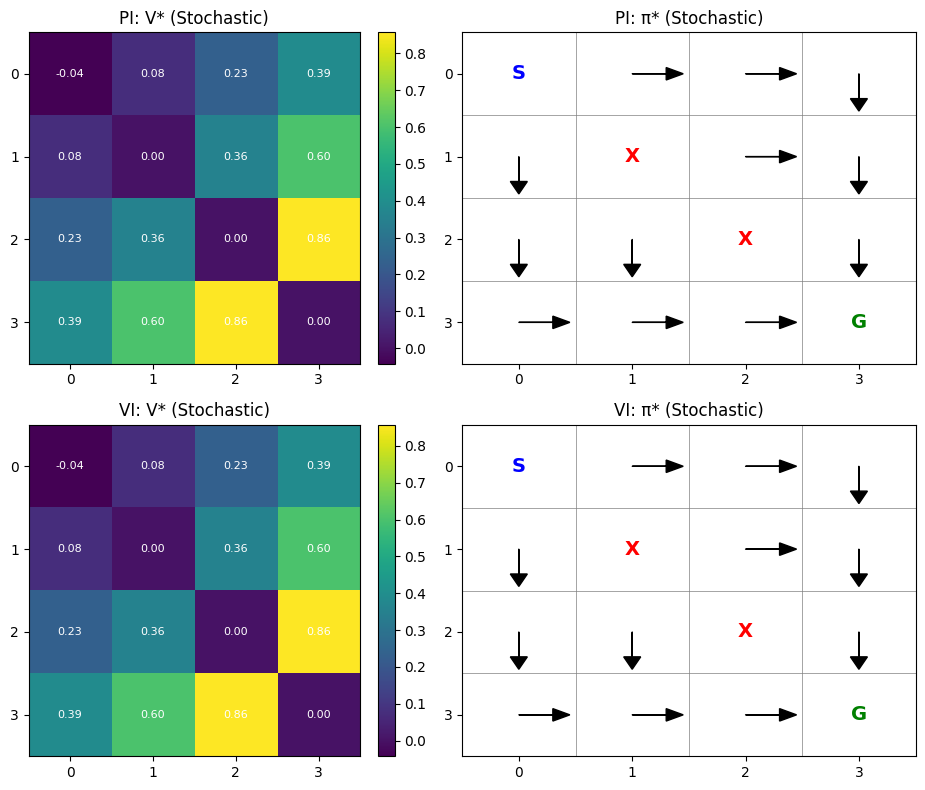

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
plot_value_function(V_pi_stoch, env_stoch, ax=axes[0,0], title="PI: V* (Stochastic)")
plot_policy(policy_pi_stoch, env_stoch, ax=axes[0,1], title="PI: π* (Stochastic)")
plot_value_function(V_vi_stoch, env_stoch, ax=axes[1,0], title="VI: V* (Stochastic)")
plot_policy(policy_vi_stoch, env_stoch, ax=axes[1,1], title="VI: π* (Stochastic)")
plt.tight_layout()
plt.show()

## 4. Application to FrozenLake‑v1

We will access the transition dynamics via `env.unwrapped.P` and apply our DP algorithms.

### 4.1 Load FrozenLake and Inspect Dynamics

In [16]:
env_fl = gym.make('FrozenLake-v1', is_slippery=True)
nS_fl = env_fl.observation_space.n
nA_fl = env_fl.action_space.n
P_fl = env_fl.unwrapped.P

print(f"FrozenLake: {nS_fl} states, {nA_fl} actions")
print("Example transitions from state 0, action 1 (Down):")
for t in P_fl[0][1]:
    print(f"  prob={t[0]:.2f}, next={t[1]}, reward={t[2]}, done={t[3]}")

FrozenLake: 16 states, 4 actions
Example transitions from state 0, action 1 (Down):
  prob=0.33, next=0, reward=0, done=False
  prob=0.33, next=4, reward=0, done=False
  prob=0.33, next=1, reward=0, done=False


### 4.2 Adapt DP Functions for FrozenLake

Our DP functions expect an object with `.P`, `.nS`, `.nA` attributes. FrozenLake's `env.unwrapped` provides `.P`. We can create a simple wrapper.

In [17]:
class FrozenLakeWrapper:
    def __init__(self, env):
        self.P = env.unwrapped.P
        self.nS = env.observation_space.n
        self.nA = env.action_space.n
        self.env = env

    def _state_to_rc(self, s):
        return divmod(s, 4)  # FrozenLake is 4x4

fl_wrapper = FrozenLakeWrapper(env_fl)

### 4.3 Run Policy Iteration and Value Iteration

In [18]:
policy_pi_fl, V_pi_fl, eval_iters_fl, time_pi_fl = policy_iteration(fl_wrapper, gamma=0.99, theta=1e-8, inplace_eval=True)
policy_vi_fl, V_vi_fl, deltas_vi_fl, time_vi_fl = value_iteration(fl_wrapper, gamma=0.99, theta=1e-8, inplace=True)

print(f"PI: Outer iterations = {len(eval_iters_fl)}, time = {time_pi_fl:.4f}s")
print(f"VI: Sweeps = {len(deltas_vi_fl)}, time = {time_vi_fl:.4f}s")

PI: Outer iterations = 3, time = 0.0922s
VI: Sweeps = 324, time = 0.0700s


### 4.4 Visualize FrozenLake Results

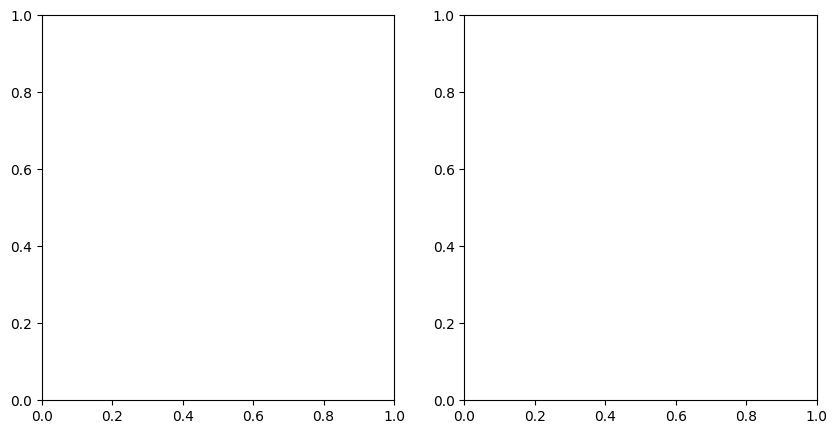

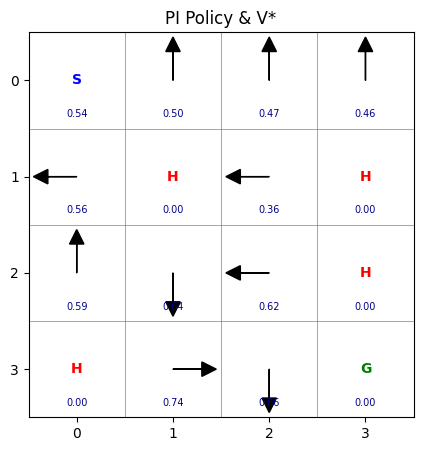

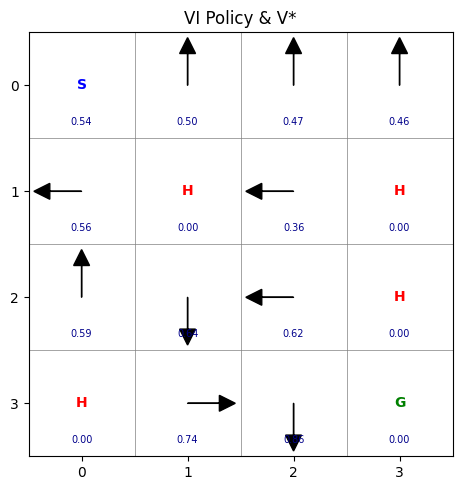

In [19]:
def plot_frozenlake_policy(policy, V, title):
    fig, ax = plt.subplots(figsize=(5,5))
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(-0.5, 3.5)
    ax.set_aspect('equal')
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.invert_yaxis()
    # Draw grid
    for i in range(5):
        ax.axhline(i-0.5, color='gray', lw=0.5)
        ax.axvline(i-0.5, color='gray', lw=0.5)

    # FrozenLake map: S=start, F=frozen, H=hole, G=goal
    map_desc = ['SFFF', 'FHFH', 'FFFH', 'HFFG']
    for r in range(4):
        for c in range(4):
            s = r*4 + c
            tile = map_desc[r][c]
            if tile == 'S':
                ax.text(c, r, 'S', ha='center', va='center', fontweight='bold', color='blue')
            elif tile == 'G':
                ax.text(c, r, 'G', ha='center', va='center', fontweight='bold', color='green')
            elif tile == 'H':
                ax.text(c, r, 'H', ha='center', va='center', fontweight='bold', color='red')
            else:
                # Draw arrow
                if np.sum(policy[s]) > 0.99:
                    a = np.argmax(policy[s])
                    dx, dy = {0: (-0.3, 0), 1: (0, 0.3), 2: (0.3, 0), 3: (0, -0.3)}[a]
                    ax.arrow(c, r, dx, dy, head_width=0.15, head_length=0.15, fc='black', ec='black')
            # Value annotation
            ax.text(c, r+0.35, f'{V[s]:.2f}', ha='center', va='center', fontsize=7, color='darkblue')

    ax.set_title(title)
    return ax

fig, axes = plt.subplots(1, 2, figsize=(10,5))
plot_frozenlake_policy(policy_pi_fl, V_pi_fl, "PI Policy & V*")
plot_frozenlake_policy(policy_vi_fl, V_vi_fl, "VI Policy & V*")
plt.tight_layout()
plt.show()

### 4.5 Convergence Curves Comparison

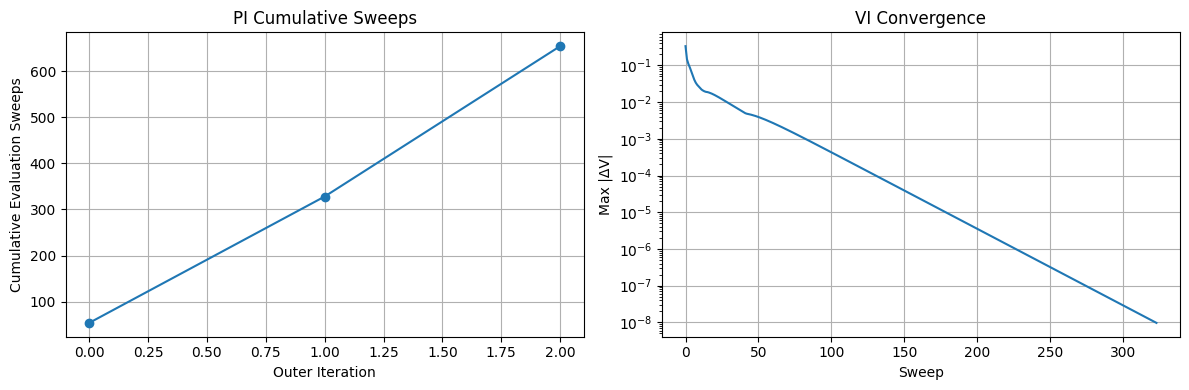

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

ax1.plot(np.cumsum(eval_iters_fl), marker='o')
ax1.set_xlabel("Outer Iteration")
ax1.set_ylabel("Cumulative Evaluation Sweeps")
ax1.set_title("PI Cumulative Sweeps")
ax1.grid(True)

ax2.plot(deltas_vi_fl)
ax2.set_xlabel("Sweep")
ax2.set_ylabel("Max |ΔV|")
ax2.set_yscale('log')
ax2.set_title("VI Convergence")
ax2.grid(True)

plt.tight_layout()
plt.show()

## 5. Discussion and Analysis

**Convergence Speed:**
- In the deterministic GridWorld, Policy Iteration converged in very few outer iterations (often 2-4) but each evaluation phase performed many sweeps. Value Iteration took more sweeps overall but each sweep is cheaper.
- In‑place policy evaluation converged faster than synchronous evaluation because it propagates new information immediately.
- For the stochastic environment, the optimal policy differs from the deterministic case. The agent often takes longer, safer routes to avoid slipping into obstacles.

**FrozenLake Observations:**
- With `is_slippery=True`, the optimal policy often points towards walls to avoid slipping into holes. The value function is much lower than the deterministic variant.
- Policy Iteration typically requires fewer outer iterations but more total evaluation sweeps. Value Iteration may be simpler to implement and can be faster in wall‑clock time for small problems.

**When to use DP:**
- DP is applicable when the full MDP model is known and the state space is small enough to be tabular. It provides exact solutions and serves as a baseline for approximate methods.

**Limitations:**
- The curse of dimensionality limits DP to small state spaces. For larger or continuous problems, function approximation or sampling methods (Monte Carlo, TD) are required.

## 6. Conclusion

In this lab, we:
- Built a configurable GridWorld environment with deterministic and stochastic dynamics.
- Implemented synchronous and in‑place versions of policy evaluation.
- Implemented Policy Iteration and Value Iteration.
- Visualized value functions and policies.
- Compared convergence behavior across different environments and algorithm variants.
- Applied DP to Gymnasium’s FrozenLake‑v1.

These implementations reinforce the core concepts of Dynamic Programming and prepare us for model‑free reinforcement learning methods in subsequent weeks.